<a id="sec-title"></a>

# **Computational Urban Comfort Indexing and Annealed Optimisation for Latent Potentials**

**Authors:** [Sijie Yang](https://sijie-yang.com), [Zdravko Trivic](https://cde.nus.edu.sg/arch/staffs/zdravko-trivic-dr/), [Yihan Zhu](https://ual.sg/author/yihan-zhu/), [Mahmoud Abdelrahman](https://ual.sg/author/mahmoud-abdelrahman/), [Filip Biljecki](https://filipbiljecki.com)*

by [Urban Analytics Lab](https://ual.sg), [Department of Architecture](https://cde.nus.edu.sg/arch/), [College of Design and Engineering](https://cde.nus.edu.sg), [National University of Singapore](https://www.nus.edu.sg)

---

**Note:** Each .ipynb file can be run independently. This work is licensed under a [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).

**All notebooks in this project (code series):**

- <a href="code_0_social_media_post_embedding.ipynb" target="_blank" rel="noopener noreferrer">code_0 — social media post embedding</a>
- <a href="code_1_social_activity_data.ipynb" target="_blank" rel="noopener noreferrer">code_1 — social activity data</a>
- <a href="code_2_geospatial_data.ipynb" target="_blank" rel="noopener noreferrer">code_2 — geospatial data</a>
- <a href="code_3_uci_social_activity_field.ipynb" target="_blank" rel="noopener noreferrer">code_3 — UCI social activity field</a>
- <a href="code_4_uci_causal_forest.ipynb" target="_blank" rel="noopener noreferrer">code_4 — UCI causal forest</a>
- <a href="code_5_uci_resident_expert_survey.ipynb" target="_blank" rel="noopener noreferrer">code_5 — resident & expert survey for UCI modelling</a>
- <a href="code_6_uci_modelling.ipynb" target="_blank" rel="noopener noreferrer">code_6 — UCI modelling</a>
- <a href="code_7_uci_optimisation_puci.ipynb" target="_blank" rel="noopener noreferrer">code_7 — UCI optimisation (pUCI & UCP)</a>
- <a href="code_8_result_analytics.ipynb" target="_blank" rel="noopener noreferrer">code_8 — result analytics</a>

**Abbreviations used in this codebase series:**  
- Comfort metrics: `UCI` (Urban Comfort Index), `UCP` (Urban Comfort Potential), `pUCI` (policy-driven Urban Comfort Index).  
- Variation metrics: `SSV` (Social-Spatial Variation), `SVI` (Social Variation Index), `SPVI` (Spatial Variation Index), `SSVI` (Socio-Spatial Variation Index).  
- Geospatial dimensions: `SP` (Streetscape Perception), `FC` (Functionality), `AC` (Accessibility), `CD` (Contact Density).
- Model and dimensions: `HGWR` (Hierarchical Geographically Weighted Regression), `CATE` (Conditional Average Treatment Effect).


<a id="sec-overview"></a>

## Data: Social Activity Data

This notebook **explores and visualises** grid-level social activity fields produced by [code_0](code_0_social_media_post_embedding.ipynb): category post counts (activity intensity / activity support), caption-based experience quality, social activity comfort, and derived spatial summaries. Outputs are consumed by [code_3](code_3_uci_social_activity_field.ipynb) onward.

**Prerequisites:** Run code_0 §3–§4 (or use the committed `data/data_social_activity.gpkg`).

**Inputs:**
- `data/data_social_activity.gpkg` — grid fields from code_0 §3.3–§4.4

**Outputs (in-memory):**
- `act_gdf` with derived columns: `prevalent_activity`, `total_activity`, `prevalent_comfort_activity`, `total_social_activity_comfort`, LISA diagnostics (§4)

**Figures (`figure/`):**
- `code_1_social_media_post_filtering.png` (§1.1; SI Fig.~post filtering)
- `code_1_social_activity_data.png` (§2.4)
- `code_1_social_activity_comfort.png`, `.svg` (§3.4; exploratory — main paper uses code_0 three-panel maps)
- `code_1_moran_lisa.png` (§4.2; candidate SI figure)

**Terminology (paper ↔ code):** same as code_0 — activity **support** $=$ activity **intensity** $=$ post count (`eating`, …); **social activity comfort** $=$ intensity $	imes$ `avg_comfort_{category}`.

**Section list:**

- [Title & license](#sec-title)
- [1. Post-level filtering flow (Sankey)](#sec-1-filtering)
  - [1.1 Sankey diagram and export](#sec-1-1-sankey)
- [2. Grid activity intensity](#sec-2-intensity)
  - [2.1 Load and validate GPKG](#sec-2-1-load)
  - [2.2 Prevalent activity and total intensity](#sec-2-2-prevalent)
  - [2.3 Distribution and bar charts](#sec-2-3-summary)
  - [2.4 Spatial maps](#sec-2-4-maps)
- [3. Social activity comfort](#sec-3-comfort)
  - [3.1 Derived comfort aggregates](#sec-3-1-derive)
  - [3.2 Per-category comfort maps](#sec-3-2-category-maps)
  - [3.3 Distribution and bar charts](#sec-3-3-summary)
  - [3.4 Total and prevalent comfort maps](#sec-3-4-maps)
- [4. Spatial autocorrelation (Moran's I)](#sec-4-moran)
  - [4.1 Global Moran's I per category](#sec-4-1-global)
  - [4.2 Moran scatterplot and LISA map](#sec-4-2-lisa)
- [5. Handover](#sec-5-handover)
  - [5.1 Schema summary for downstream notebooks](#sec-5-1-schema)


<a id="sec-1-filtering"></a>

## 1. Post-level filtering flow (Sankey)

Sankey diagram of post counts from the aligned corpus ($N=44{,}228$) through caption availability, cluster selection (C0, C2, C3, C5, C6, C7 mapped; C1, C4 excluded), and five activity categories. Counts are fixed from the code_0 pipeline; reproduced here for SI Fig.~post filtering.

**Inputs:** hard-coded stage counts (from code_0 clustering export).

**Outputs:** `figure/code_1_social_media_post_filtering.png`

**Subsections:**
- [1.1 Sankey diagram and export](#sec-1-1-sankey)


<a id="sec-1-1-sankey"></a>

### 1.1 Sankey diagram and export

Plotly Sankey with fixed node layout; saves PNG for paper/SI (`fig_social_media_post_filtering.png` after copy to `paper/fig/`).


In [33]:
# §1.1 — Sankey post-filtering flow
import plotly.graph_objects as go
from pathlib import Path

FIGURE_DIR = Path('figure')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Flow:
# 1. Raw posts → posts with caption / posts without caption
# 2. Each splits into: used for clustering / excluded from cluster
# 3. Clustered posts further split into 5 activity categories

labels = [
    "Retrieved raw posts\n44,228",     # 0 - Raw posts
    "Posts with captions\n38,987",     # 1 - With caption
    "Posts without captions\n5,241",   # 2 - Without caption
    "Cluster selected posts\n33,250\n(C0, C2, C3, C5, C6, C7)",  # 3
    "Cluster excluded posts\n10,978\n(C1, C4)",  # 4
    "Eating posts\n10,313\n(C0, C6)",            # 5
    "Nature posts\n3,834\n(C3)",             # 6
    "Community posts\n6,449\n(C5)",          # 7
    "Walking posts\n6,470\n(C2)",            # 8
    "Sightseeing posts\n6,184\n(C7)",        # 9
]

# Source and target node indices for each flow
source = [
    0, 0,           # raw → caption / no caption
    1, 1, 2, 2,     # with/without caption → clustered/excluded
    3, 3, 3, 3, 3,  # clustered→5 activities
]

target = [
    1, 2,
    3, 4, 3, 4,
    5, 6, 7, 8, 9,
]

# Flow values representing counts at each stage
value = [
    38987, 5241,
    29218, 9769, 4032, 1209,
    10313, 3834, 6449, 6470, 6184,
]

# Column x: 8% inset from each side (0.08 … 0.92), evenly spaced — keeps ribbons wide
# and left/right label gutters visually balanced without shrinking the plot.
COL_X = (0.03, 0.30, 0.58, 0.97)
node_x = [
    COL_X[0],
    COL_X[1], COL_X[1],
    COL_X[2], COL_X[2],
    COL_X[3], COL_X[3], COL_X[3], COL_X[3], COL_X[3],
]
node_y = [
    0.52,
    0.28, 0.82,
    0.30, 0.84,
    0.12, 0.28, 0.46, 0.64, 0.82,
]

# Sankey Diagram construction
fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="fixed",
            node=dict(
                pad=30,
                thickness=16,
                line=dict(color="rgba(80,80,80,0.5)", width=0.8),
                label=labels,
                x=node_x,
                y=node_y,
                color=[
                    "#BDDF26",                # Raw
                    "#72B7B2", "#E45756",     # Caption splits
                    "#7C7C7C", "#BAB0AC",     # Clustered / not
                    "#FF5445", "#29BB00", "#FFBC37", "#35A7FF", "#B339FF",  # Activities
                ],
            ),
            link=dict(
                source=source,
                target=target,
                value=value,
                color=[
                    "rgba(189,223,38,0.42)", "rgba(189,223,38,0.42)",
                    "rgba(114,183,178,0.45)", "rgba(114,183,178,0.26)",
                    "rgba(228,87,86,0.45)", "rgba(228,87,86,0.26)",
                    "rgba(255,84,69,0.5)",
                    "rgba(41,187,0,0.5)",
                    "rgba(255,188,55,0.5)",
                    "rgba(53,167,255,0.5)",
                    "rgba(179,57,255,0.5)",
                ],
            ),
        )
    ]
)

SIDE_MARGIN = 12  # equal left/right gutter for node labels (px)

fig.update_layout(
    title=dict(
        text="Social Media Post Data Filtering",
        x=0.5,
        xanchor="center",
        y=0.96,
        yanchor="top",
        pad=dict(b=8),
        font=dict(size=18, family="Arial"),
    ),
    font=dict(size=16, family="Arial"),
    width=1400,
    height=880,
    margin=dict(l=SIDE_MARGIN, r=SIDE_MARGIN, t=120, b=0),
    paper_bgcolor="white",
    plot_bgcolor="white",
)

out_png = FIGURE_DIR / "code_1_social_media_post_filtering.png"
fig.write_image(out_png, scale=2)
print(f"Saved {out_png.resolve()}")

fig.show()


Saved /Users/sijieyang/Documents/Urban-Comfort-Potential/figure/code_1_social_media_post_filtering.png


<a id="sec-2-intensity"></a>

## 2. Grid activity intensity

We use social-media posting counts at each grid location $\mathbf{u}$ as a proxy of observed social activity intensity (paper: **activity support**):

$$\text{Activity Category Set } i = \{\textit{eating}, \textit{nature}, \textit{community}, \textit{walking}, \textit{sightseeing}\}$$

$$\text{SocialActivityIntensity}_{i,\mathbf{u}} = \text{PostNum}_{i,\mathbf{u}}$$

**Subsections:**
- [2.1 Load and validate GPKG](#sec-2-1-load)
- [2.2 Prevalent activity and total intensity](#sec-2-2-prevalent)
- [2.3 Distribution and bar charts](#sec-2-3-summary)
- [2.4 Spatial maps](#sec-2-4-maps)


<a id="sec-2-1-load"></a>

### 2.1 Load and validate GPKG

Load `data/data_social_activity.gpkg`, set shared constants (`ACT_COLUMNS`, colours, `FIGURE_DIR`), and print category post totals.


In [34]:
# §2.1 — load grid social activity GPKG
from pathlib import Path

import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt

DATA_PATH = Path('data/data_social_activity.gpkg')
FIGURE_DIR = Path('figure')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

ACT_COLUMNS = ['eating', 'nature', 'community', 'walking', 'sightseeing']
COMFORT_COLUMNS = [f'social_activity_comfort_{c}' for c in ACT_COLUMNS]
ACTIVITY_COLORS = {
    'eating': '#FF5445',
    'nature': '#29BB00',
    'community': '#FFBC37',
    'walking': '#35A7FF',
    'sightseeing': '#B339FF',
    'none': '#440154',
}

act_gdf = gpd.read_file(DATA_PATH)
act_gdf.crs = 'EPSG:4326'

print(act_gdf.crs)
print(list(act_gdf.columns))
for col in ACT_COLUMNS:
    print(f'Total posts ({col}): {act_gdf[col].sum():,.0f}')
print(f'Total posts (all categories): {act_gdf[ACT_COLUMNS].sum().sum():,.0f}')


EPSG:4326
['id', 'longitude', 'latitude', 'eating', 'nature', 'community', 'walking', 'sightseeing', 'avg_comfort_score', 'avg_comfort_eating', 'avg_comfort_nature', 'avg_comfort_community', 'avg_comfort_walking', 'avg_comfort_sightseeing', 'social_activity_comfort_eating', 'social_activity_comfort_nature', 'social_activity_comfort_community', 'social_activity_comfort_walking', 'social_activity_comfort_sightseeing', 'geometry']
Total posts (eating): 10,326
Total posts (nature): 3,777
Total posts (community): 6,459
Total posts (walking): 6,473
Total posts (sightseeing): 6,201
Total posts (all categories): 33,236


<a id="sec-2-2-prevalent"></a>

### 2.2 Prevalent activity and total intensity

For each location $\mathbf{u}$, prevalent activity is the category with highest post count; `none` if all zeros. Total intensity is the row sum over categories.


In [35]:
# §2.2 — prevalent activity and total intensity
act_gdf['prevalent_activity'] = act_gdf[ACT_COLUMNS].idxmax(axis=1)
act_gdf.loc[act_gdf[ACT_COLUMNS].sum(axis=1) == 0, 'prevalent_activity'] = 'none'
act_gdf['total_activity'] = act_gdf[ACT_COLUMNS].sum(axis=1)


<a id="sec-2-3-summary"></a>

### 2.3 Distribution and bar charts

Histogram of `total_activity` per grid and bar chart of grid counts by `prevalent_activity`.


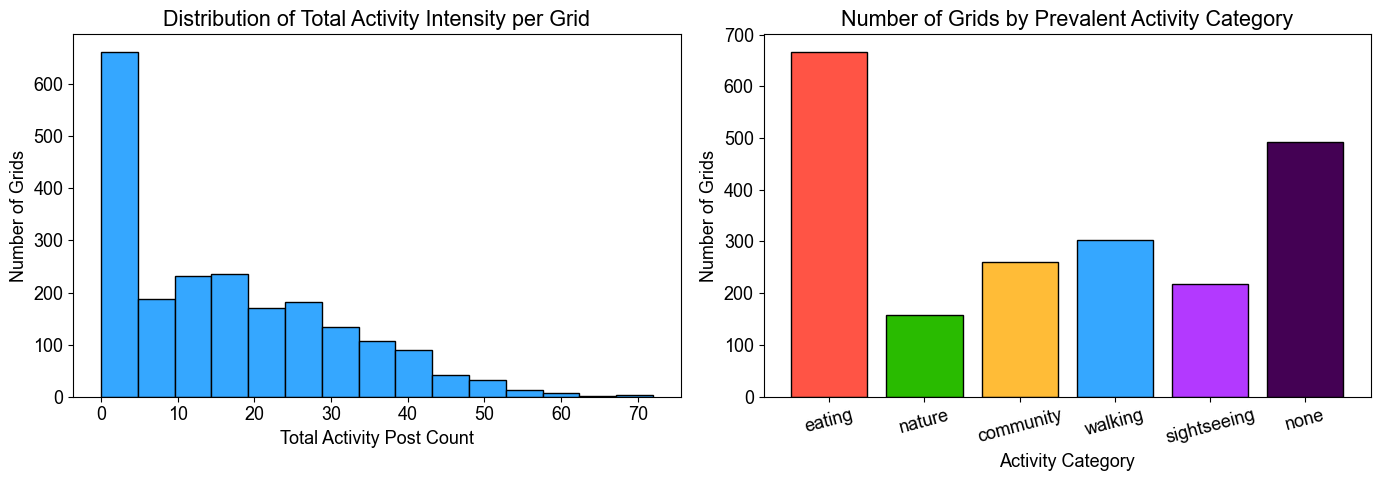

In [36]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# §2.3 — intensity distribution and prevalent-activity bar charts
# Plot two-related charts: (1) Total Activity (all grids) distribution histogram, (2) Bar: Number of Grids by Prevalent Social Activity Category
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar 1 (now first figure): Histogram of total activity count distribution
axes[0].hist(act_gdf['total_activity'], bins=15, color="#35A7FF", edgecolor="black")
axes[0].set_title('Distribution of Total Activity Intensity per Grid')
axes[0].set_xlabel('Total Activity Post Count')
axes[0].set_ylabel('Number of Grids')

# Bar 2 (move original bar to here): Number of Grids by Prevalent Social Activity Category
prevalent_counts = act_gdf['prevalent_activity'].value_counts().reindex(ACT_COLUMNS + ['none']).fillna(0)
axes[1].bar(prevalent_counts.index, prevalent_counts.values, color=[
    '#FF5445', '#29BB00', '#FFBC37', '#35A7FF', '#B339FF', '#440154'
], edgecolor="black")
axes[1].set_title('Number of Grids by Prevalent Activity Category')
axes[1].set_ylabel('Number of Grids')
axes[1].set_xlabel('Activity Category')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


<a id="sec-2-4-maps"></a>

### 2.4 Spatial maps

Choropleth of total activity intensity and categorical map of prevalent activity. Saved as `figure/code_1_social_activity_data.png`.


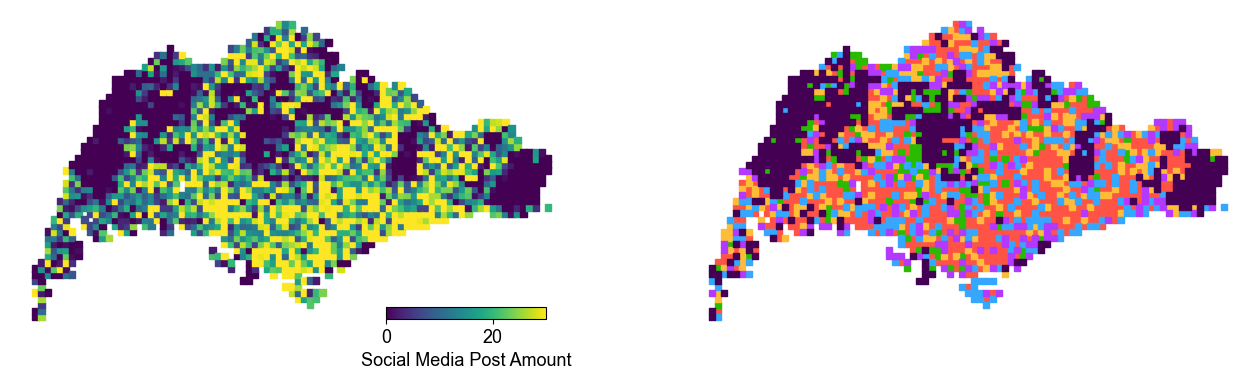

In [37]:
# §2.4 — spatial maps of activity intensity
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# First plot: show the distribution of total_activity
act_gdf.plot(ax=axes[0], vmin=0, vmax=30, column='total_activity', marker='s', markersize=22)
axes[0].axis('off')

# Create a ScalarMappable with the colormap and value range used in the plot
norm = mpl.colors.Normalize(vmin=0, vmax=30)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)  # Use the same colormap as in the plot
sm.set_array([])  # ScalarMappable is only for the colorbar

# # Add a colorbar to the figure
# # Adjust layout to make room for the colorbar at the bottom
cbar_ax = fig.add_axes([0.36, 0.31, 0.1, 0.015])  # [left, bottom, width, height]

# Create the colorbar with horizontal orientation
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Social Media Post Amount')  # Set colorbar label

# Second plot: display each location colored by most prevalent activity category
# ACTIVITY_COLORS defined in §2.1

for activity, color in ACTIVITY_COLORS.items():
    subset = act_gdf[act_gdf['prevalent_activity'] == activity]
    subset.plot(ax=axes[1], color=color, marker='s', markersize=19)

axes[1].axis('off')

fig.savefig(FIGURE_DIR / "code_1_social_activity_data.png", dpi=300, bbox_inches="tight")
plt.show()


<a id="sec-3-comfort"></a>

## 3. Social activity comfort

For each activity category $i$ and location $\mathbf{u}$, **social activity comfort** combines intensity and category-specific experience quality (paper Eq.~social activity comfort):

$$\text{SocialActivityComfort}_{i,\mathbf{u}} = \text{SocialActivityIntensity}_{i,\mathbf{u}} \times \text{ExperienceQuality}_{i,\mathbf{u}}$$

Grid columns: `social_activity_comfort_{eating,nature,...}` (product of post count and `avg_comfort_{category}`).

**Subsections:**
- [3.1 Derived comfort aggregates](#sec-3-1-derive)
- [3.2 Per-category comfort maps](#sec-3-2-category-maps)
- [3.3 Distribution and bar charts](#sec-3-3-summary)
- [3.4 Total and prevalent comfort maps](#sec-3-4-maps)


<a id="sec-3-1-derive"></a>

### 3.1 Derived comfort aggregates

Compute `prevalent_comfort_activity` (argmax over comfort surfaces) and `total_social_activity_comfort` (row sum). Run before §3.2 maps.


In [38]:
# §3.1 — prevalent comfort activity and total social activity comfort
# Prevalent comfort activity (argmax over per-category social activity comfort) and total (sum), parallel to Section 2.
# idxmax on comfort_cols returns long names (social_activity_comfort_eating); align with ACT_COLUMNS like Section 2.
comfort_cols = [f'social_activity_comfort_{c}' for c in ACT_COLUMNS]
_comfort_for_argmax = act_gdf[comfort_cols].fillna(0).copy()
_comfort_for_argmax.columns = ACT_COLUMNS
act_gdf['prevalent_comfort_activity'] = _comfort_for_argmax.idxmax(axis=1)
act_gdf.loc[_comfort_for_argmax.sum(axis=1) == 0, 'prevalent_comfort_activity'] = 'none'
act_gdf['total_social_activity_comfort'] = act_gdf[comfort_cols].sum(axis=1)


<a id="sec-3-2-category-maps"></a>

### 3.2 Per-category comfort maps

Five-panel choropleth of `social_activity_comfort_*` (display only; paper SI uses code_0 three-panel maps).


/var/folders/f4/33sk92_n60j6tssngt9ntw3m0000gn/T/ipykernel_32754/588284615.py:46: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



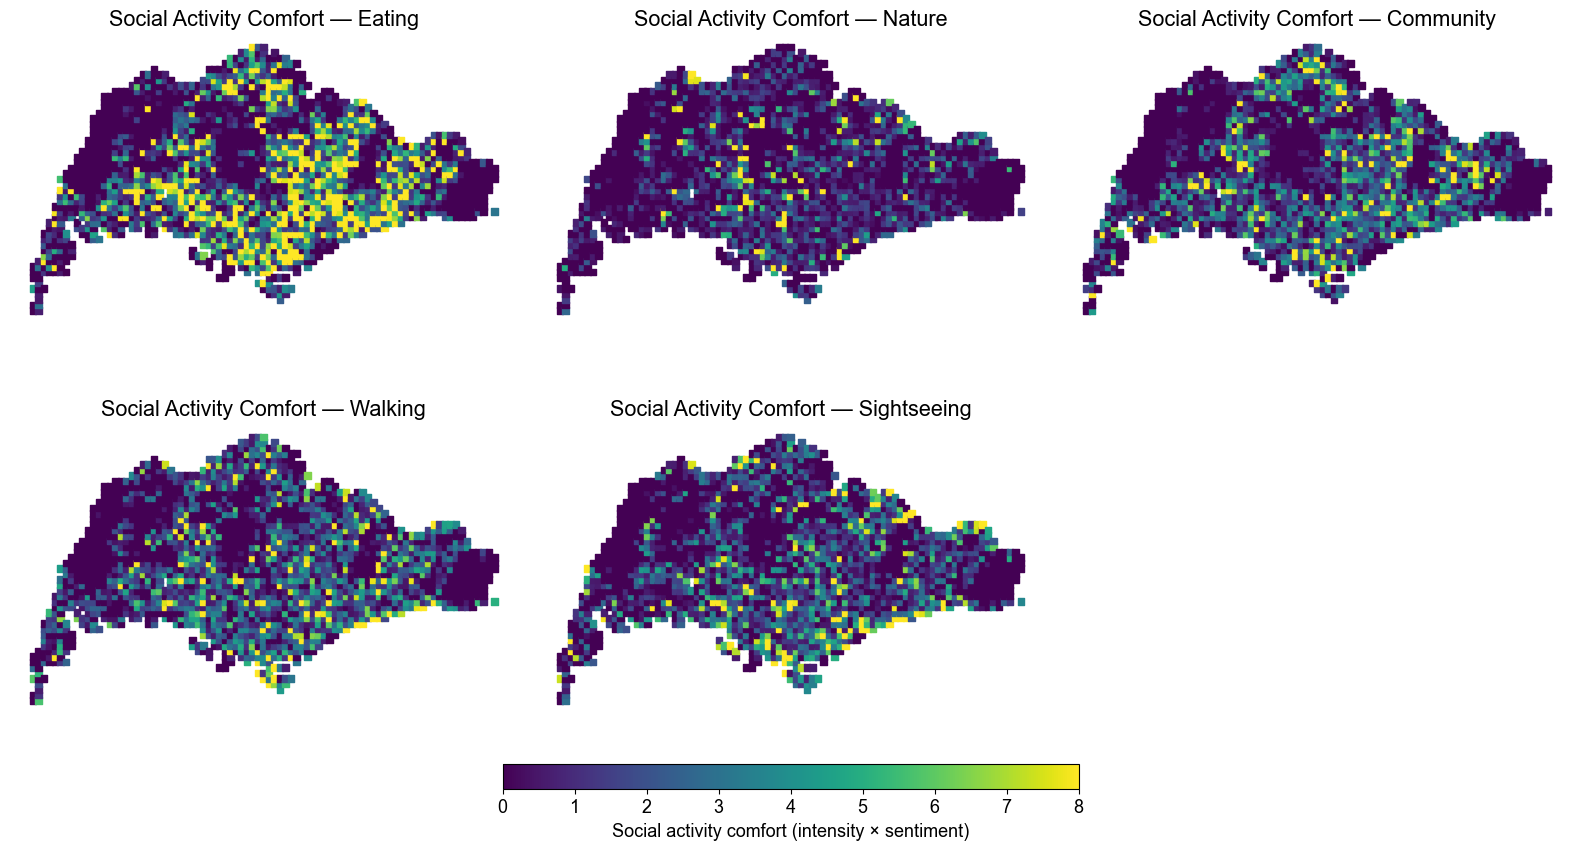

In [39]:
# §3.2 — per-category social activity comfort maps
# Plot five social activity comfort maps (same style as Section 2: square markers, viridis color map, axes off)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

comfort_columns = [f'social_activity_comfort_{c}' for c in ACT_COLUMNS]
vmax = 8
vmin = 0.0
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.viridis

title_map = {
    'eating': 'Social Activity Comfort — Eating',
    'nature': 'Social Activity Comfort — Nature',
    'community': 'Social Activity Comfort — Community',
    'walking': 'Social Activity Comfort — Walking',
    'sightseeing': 'Social Activity Comfort — Sightseeing',
}

for idx, category in enumerate(ACT_COLUMNS):
    column = f'social_activity_comfort_{category}'
    act_gdf.plot(
        ax=axes[idx],
        column=column,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        marker='s',
        markersize=22,
        legend=False,
    )
    axes[idx].set_title(title_map[category])
    axes[idx].axis('off')

# Hide the unused sixth axis
axes[5].axis('off')

# Create a horizontal colorbar below the subplots
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Add horizontal colorbar at the bottom of the figure
cbar_ax = fig.add_axes([0.32, 0.15, 0.36, 0.025])  # [left, bottom, width, height]
fig.colorbar(sm, cax=cbar_ax, orientation='horizontal', label='Social activity comfort (intensity × sentiment)')

plt.tight_layout(rect=[0, 0.13, 1, 1])  # Leave extra space at the bottom for the colorbar
plt.show()


<a id="sec-3-3-summary"></a>

### 3.3 Distribution and bar charts

Histogram of total social activity comfort and bar chart by prevalent comfort activity.


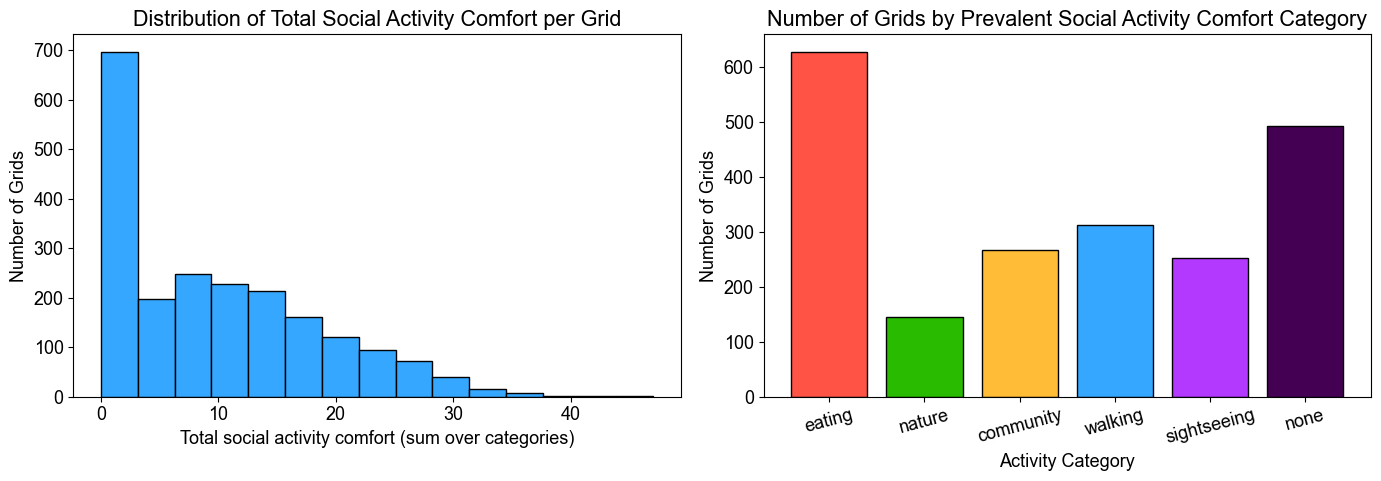

In [40]:
# §3.3 — comfort distribution and prevalent-comfort bar charts
# Two summary charts: (1) distribution of total social activity comfort, (2) grid counts by prevalent comfort activity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(act_gdf['total_social_activity_comfort'], bins=15, color="#35A7FF", edgecolor="black")
axes[0].set_title('Distribution of Total Social Activity Comfort per Grid')
axes[0].set_xlabel('Total social activity comfort (sum over categories)')
axes[0].set_ylabel('Number of Grids')

prevalent_comfort_counts = act_gdf['prevalent_comfort_activity'].value_counts().reindex(ACT_COLUMNS + ['none']).fillna(0)
axes[1].bar(prevalent_comfort_counts.index, prevalent_comfort_counts.values, color=[
    '#FF5445', '#29BB00', '#FFBC37', '#35A7FF', '#B339FF', '#440154'
], edgecolor="black")
axes[1].set_title('Number of Grids by Prevalent Social Activity Comfort Category')
axes[1].set_ylabel('Number of Grids')
axes[1].set_xlabel('Activity Category')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


<a id="sec-3-4-maps"></a>

### 3.4 Total and prevalent comfort maps

Maps of `total_social_activity_comfort` and `prevalent_comfort_activity`. Saved as PNG and SVG under `figure/`.


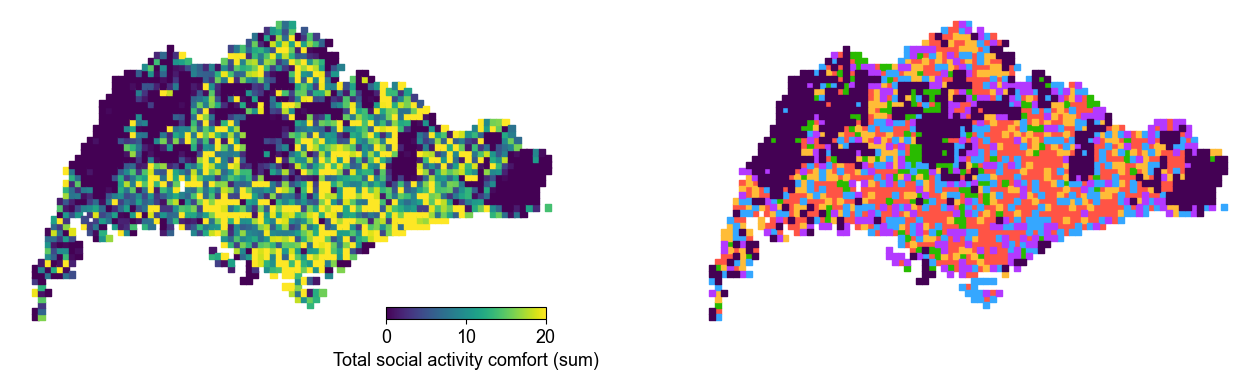

In [41]:
# §3.4 — spatial maps of total and prevalent social activity comfort
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

vmax_tot = 20
act_gdf.plot(ax=axes[0], vmin=0, vmax=vmax_tot, column='total_social_activity_comfort', marker='s', markersize=22, cmap='viridis')
axes[0].axis('off')

norm = mpl.colors.Normalize(vmin=0, vmax=vmax_tot)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.36, 0.31, 0.1, 0.015])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Total social activity comfort (sum)')

# ACTIVITY_COLORS defined in §2.1

for activity, color in ACTIVITY_COLORS.items():
    subset = act_gdf[act_gdf['prevalent_comfort_activity'] == activity]
    subset.plot(ax=axes[1], color=color, marker='s', markersize=20)

axes[1].axis('off')

fig.savefig(FIGURE_DIR / "code_1_social_activity_comfort.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "code_1_social_activity_comfort.svg", bbox_inches="tight")
plt.show()


<a id="sec-4-moran"></a>

## 4. Spatial autocorrelation (Moran's I)

Evaluate spatial clustering of social activity comfort using KNN weights ($k=8$) on grid centroids. §4.1 reports **global Moran's I** per category; §4.2 visualises aggregate total comfort (scatterplot + LISA).

**Subsections:**
- [4.1 Global Moran's I per category](#sec-4-1-global)
- [4.2 Moran scatterplot and LISA map](#sec-4-2-lisa)


<a id="sec-4-1-global"></a>

### 4.1 Global Moran's I per category

Print global $I$, expected $I$, $z$, and $p$ for each `social_activity_comfort_*` and for `total_social_activity_comfort`. Values feed SI Table~Moran (run cell to refresh numbers).


In [42]:
# §4.1 — global and local Moran's I (KNN k=8)
import numpy as np
from libpysal.weights import KNN
from libpysal.weights import lag_spatial
from esda.moran import Moran, Moran_Local

# Create a spatial weights matrix using KNN
coords = np.array([(p.x, p.y) for p in act_gdf.geometry])
w = KNN.from_array(coords, k=8)
w.transform = "r"

comfort_cols = [f"social_activity_comfort_{c}" for c in ACT_COLUMNS]

# Global Moran's I for each category's social activity comfort surface
for c in ACT_COLUMNS:
    col = f"social_activity_comfort_{c}"
    if col in act_gdf.columns:
        x = act_gdf[col]
        global_moran_cat = Moran(x, w)
        print(f"Social activity comfort ({c})")
        print(f"  Moran's I: {global_moran_cat.I:.4f}")
        print(f"  Expected I: {global_moran_cat.EI:.4f}")
        print(f"  Z-Score: {global_moran_cat.z_norm:.4f}")
        print(f"  P-Value: {global_moran_cat.p_norm:.4f}")
        print("-" * 36)
    else:
        print(f"Warning: column '{col}' not found in act_gdf.")

# total_social_activity_comfort computed in §3.1
var_total = act_gdf["total_social_activity_comfort"]

# Global Moran's I and LISA on aggregate comfort (for scatterplot and map)
x = var_total
y = x - np.mean(x)
w_x = lag_spatial(w, var_total)
global_moran = Moran(var_total, w)

local_moran = Moran_Local(var_total, w)
act_gdf["lisa_quadrant"] = local_moran.q
color_map = {1: 'red', 2: 'lightblue', 3: 'blue', 4: 'pink', 0: 'grey'}
act_gdf["color"] = act_gdf["lisa_quadrant"].map(color_map)


Social activity comfort (eating)
  Moran's I: 0.2726
  Expected I: -0.0005
  Z-Score: 25.3023
  P-Value: 0.0000
------------------------------------
Social activity comfort (nature)
  Moran's I: 0.1397
  Expected I: -0.0005
  Z-Score: 12.9848
  P-Value: 0.0000
------------------------------------
Social activity comfort (community)
  Moran's I: 0.2204
  Expected I: -0.0005
  Z-Score: 20.4709
  P-Value: 0.0000
------------------------------------
Social activity comfort (walking)
  Moran's I: 0.1813
  Expected I: -0.0005
  Z-Score: 16.8396
  P-Value: 0.0000
------------------------------------
Social activity comfort (sightseeing)
  Moran's I: 0.2053
  Expected I: -0.0005
  Z-Score: 19.0639
  P-Value: 0.0000
------------------------------------


<a id="sec-4-2-lisa"></a>

### 4.2 Moran scatterplot and LISA map

Moran scatterplot and LISA quadrant map for **total** social activity comfort. Saved as `figure/code_1_moran_lisa.png`.


Saved figure/code_1_moran_lisa.png


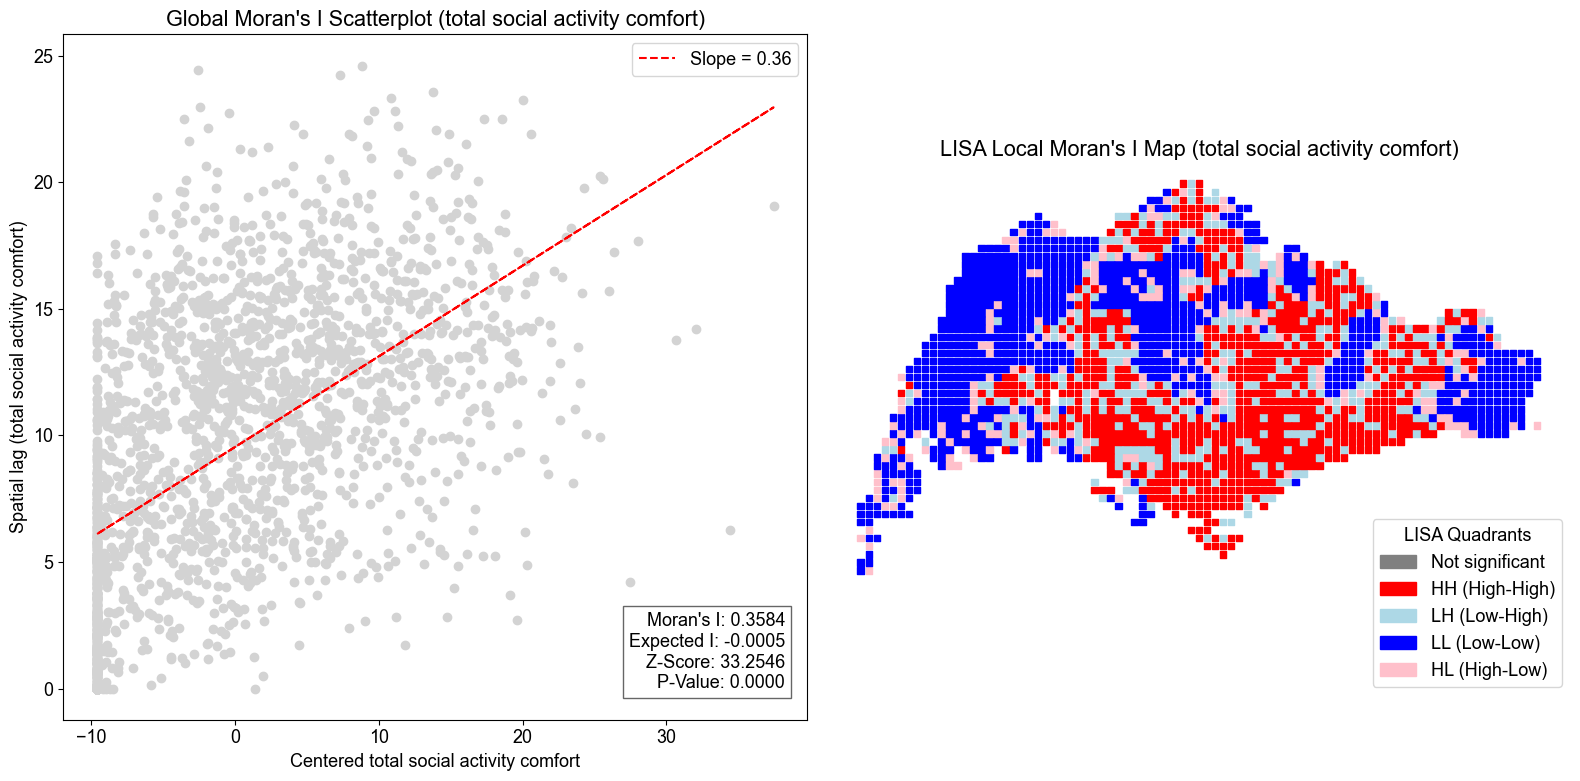

In [43]:
# §4.2 — Moran scatterplot and LISA map
# Plot two related charts in one row: (1) Global Moran's I scatterplot, (2) LISA map (total social activity comfort)
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# (1) Global Moran's I scatterplot (aggregate comfort)
axes[0].scatter(y, w_x, color='lightgrey')
b, a = np.polyfit(y, w_x, 1)
axes[0].plot(y, a + b*y, 'r--', label=f'Slope = {b:.2f}')
axes[0].text(
    0.97, 0.04,
    f"Moran's I: {global_moran.I:.4f}\n"
    f"Expected I: {global_moran.EI:.4f}\n"
    f"Z-Score: {global_moran.z_norm:.4f}\n"
    f"P-Value: {global_moran.p_norm:.4f}",
    transform=axes[0].transAxes,
    bbox=dict(facecolor='white', alpha=0.6),
    verticalalignment='bottom',
    horizontalalignment='right',
)
axes[0].set_xlabel('Centered total social activity comfort')
axes[0].set_ylabel('Spatial lag (total social activity comfort)')
axes[0].set_title("Global Moran's I Scatterplot (total social activity comfort)")
axes[0].legend()

# (2) LISA Local Moran map (aggregate comfort)
# To get a proper legend, we need to manually create legend handles
color_map = {1: 'red', 2: 'lightblue', 3: 'blue', 4: 'pink', 0: 'grey'}
lisa_labels = {
    1: "HH (High-High)", 
    2: "LH (Low-High)", 
    3: "LL (Low-Low)", 
    4: "HL (High-Low)", 
    0: "Not significant"
}
# Sort for legend order
handles = [mpatches.Patch(color=color_map[k], label=lisa_labels[k]) for k in sorted(color_map)]

act_gdf.plot(
    color=act_gdf['color'],
    ax=axes[1],
    marker='s', 
    markersize=22,
    legend=False
)
axes[1].legend(handles=handles, title="LISA Quadrants", loc='lower right', bbox_to_anchor=(1, -0.25))
axes[1].set_title("LISA Local Moran's I Map (total social activity comfort)")
axes[1].axis('off')

plt.tight_layout()
fig.savefig(FIGURE_DIR / "code_1_moran_lisa.png", dpi=300, bbox_inches="tight")
print(f"Saved {FIGURE_DIR / 'code_1_moran_lisa.png'}")
plt.show()


<a id="sec-5-handover"></a>

## 5. Handover

Summary of `act_gdf` fields for [code_3](code_3_uci_social_activity_field.ipynb) and later notebooks.

**Subsections:**
- [5.1 Schema summary](#sec-5-1-schema)


<a id="sec-5-1-schema"></a>

### 5.1 Schema summary

Print derived columns and row count. Input GPKG is read-only; downstream code_3 reads the same file plus geospatial layers.


In [44]:
# §5.1 — handover schema
derived = [
    'prevalent_activity', 'total_activity',
    'prevalent_comfort_activity', 'total_social_activity_comfort',
    'lisa_quadrant', 'color',
]
print(f'Grids: {len(act_gdf):,}')
print('Derived columns:', derived)
print(act_gdf[derived].head())


Grids: 2,096
Derived columns: ['prevalent_activity', 'total_activity', 'prevalent_comfort_activity', 'total_social_activity_comfort', 'lisa_quadrant', 'color']
  prevalent_activity  total_activity prevalent_comfort_activity  \
0               none               0                       none   
1               none               0                       none   
2        sightseeing              36                sightseeing   
3            walking               6                    walking   
4               none               0                       none   

   total_social_activity_comfort  lisa_quadrant color  
0                       0.000000              3  blue  
1                       0.000000              3  blue  
2                      19.497857              4  pink  
3                       3.291119              3  blue  
4                       0.000000              3  blue  
